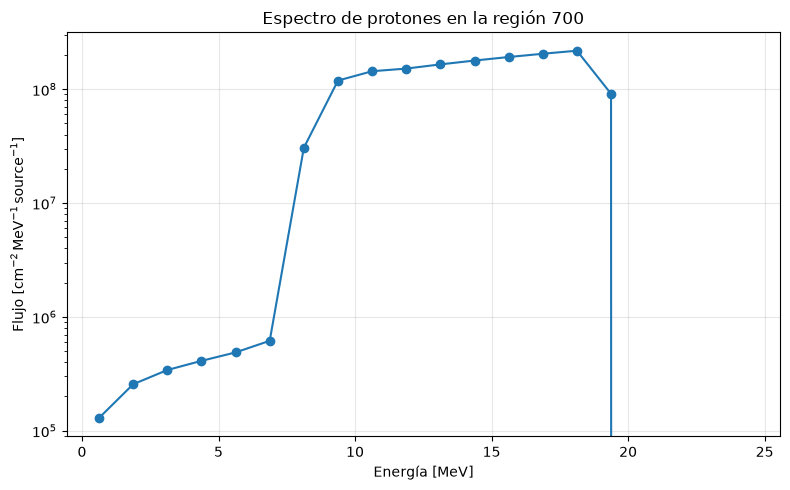

In [4]:
import numpy as np
import matplotlib.pyplot as plt

archivo = "../out/espectro_region700.out"

emin = []
emax = []
flujo = []
error_rel = []

with open(archivo, "r") as f:
    for linea in f:
        partes = linea.split()

        if len(partes) != 4:
            continue

        try:
            e1 = float(partes[0])
            e2 = float(partes[1])
            y = float(partes[2])
            err = float(partes[3])

            emin.append(e1)
            emax.append(e2)
            flujo.append(y)
            error_rel.append(err)

        except ValueError:
            continue

emin = np.array(emin)
emax = np.array(emax)
flujo = np.array(flujo)
error_rel = np.array(error_rel)

energia = (emin + emax) / 2
error_abs = flujo * error_rel

plt.figure(figsize=(8, 5))

plt.errorbar(
    energia,
    flujo,
    yerr=error_abs,
    fmt="o-",
    capsize=3
)

plt.xlabel("Energía [MeV]")
plt.ylabel(r"Flujo [$\mathrm{cm^{-2}\,MeV^{-1}\,source^{-1}}$]")
plt.title("Espectro de protones en la región 700")

plt.yscale("log")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()